<H1>5. Support Vector Machine (SVC)</H1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score
,confusion_matrix,classification_report,roc_auc_score)
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print("All are OK")

All are OK


<h3>5.1 Dataset Loading & Audit</h3>

In [3]:
df = pd.read_csv(r"C:\Users\manoh\Downloads\SEM5\Machine Learning\Capstone_Project\archive\classification.csv")
# Subsample to 10000 rows for computational efficiency
df = df.sample(n=10000, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"\nData types:\n{df.dtypes.value_counts()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Dataset shape: (10000, 75)
Columns: 75

Data types:
int64      43
float64    18
object     14
Name: count, dtype: int64

Missing values: 0
Duplicate rows: 0


<h3>5.2 Exploratory Data Analysis (EDA)</h3>

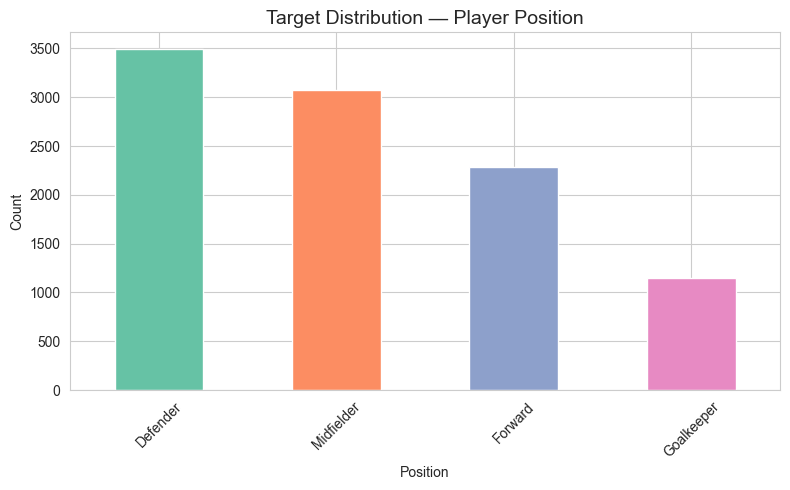


Class proportions:
position
Defender      0.3491
Forward       0.2284
Goalkeeper    0.1151
Midfielder    0.3074
Name: proportion, dtype: float64


In [4]:
# Target distribution
fig, ax = plt.subplots(figsize=(8, 5))
df['position'].value_counts().plot(kind='bar', ax=ax, color=sns.color_palette('Set2'))
ax.set_title('Target Distribution — Player Position', fontsize=14)
ax.set_xlabel('Position')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\nClass proportions:")
print(df['position'].value_counts(normalize=True).sort_index().round(4))

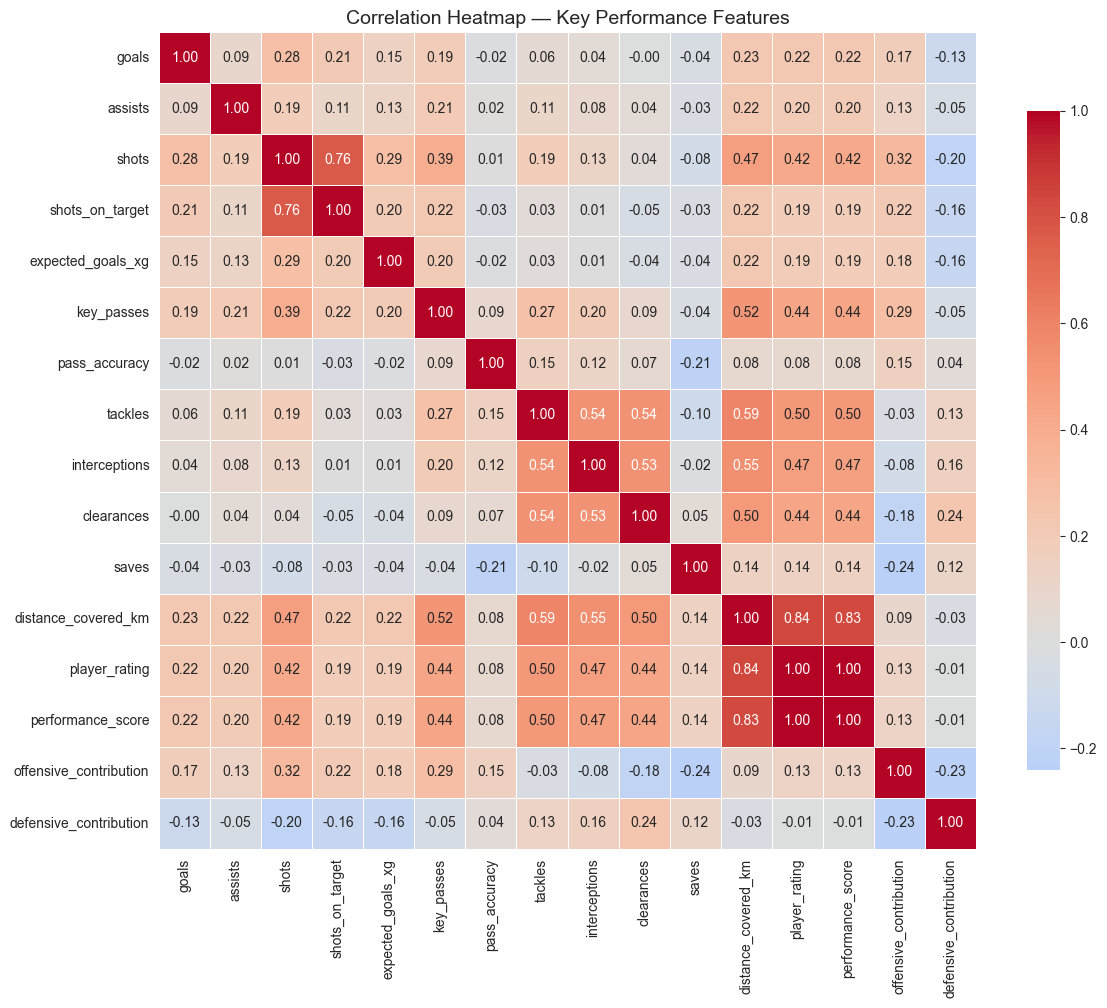

In [5]:
# Correlation heatmap — selected key features only (not all 75 columns)
heatmap_cols = ['goals','assists','shots','shots_on_target','expected_goals_xg',
                'key_passes','pass_accuracy','tackles','interceptions','clearances',
                'saves','distance_covered_km','player_rating','performance_score',
                'offensive_contribution','defensive_contribution']

plt.figure(figsize=(12, 10))
corr_matrix = df[heatmap_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Key Performance Features', fontsize=14)
plt.tight_layout()
plt.show()

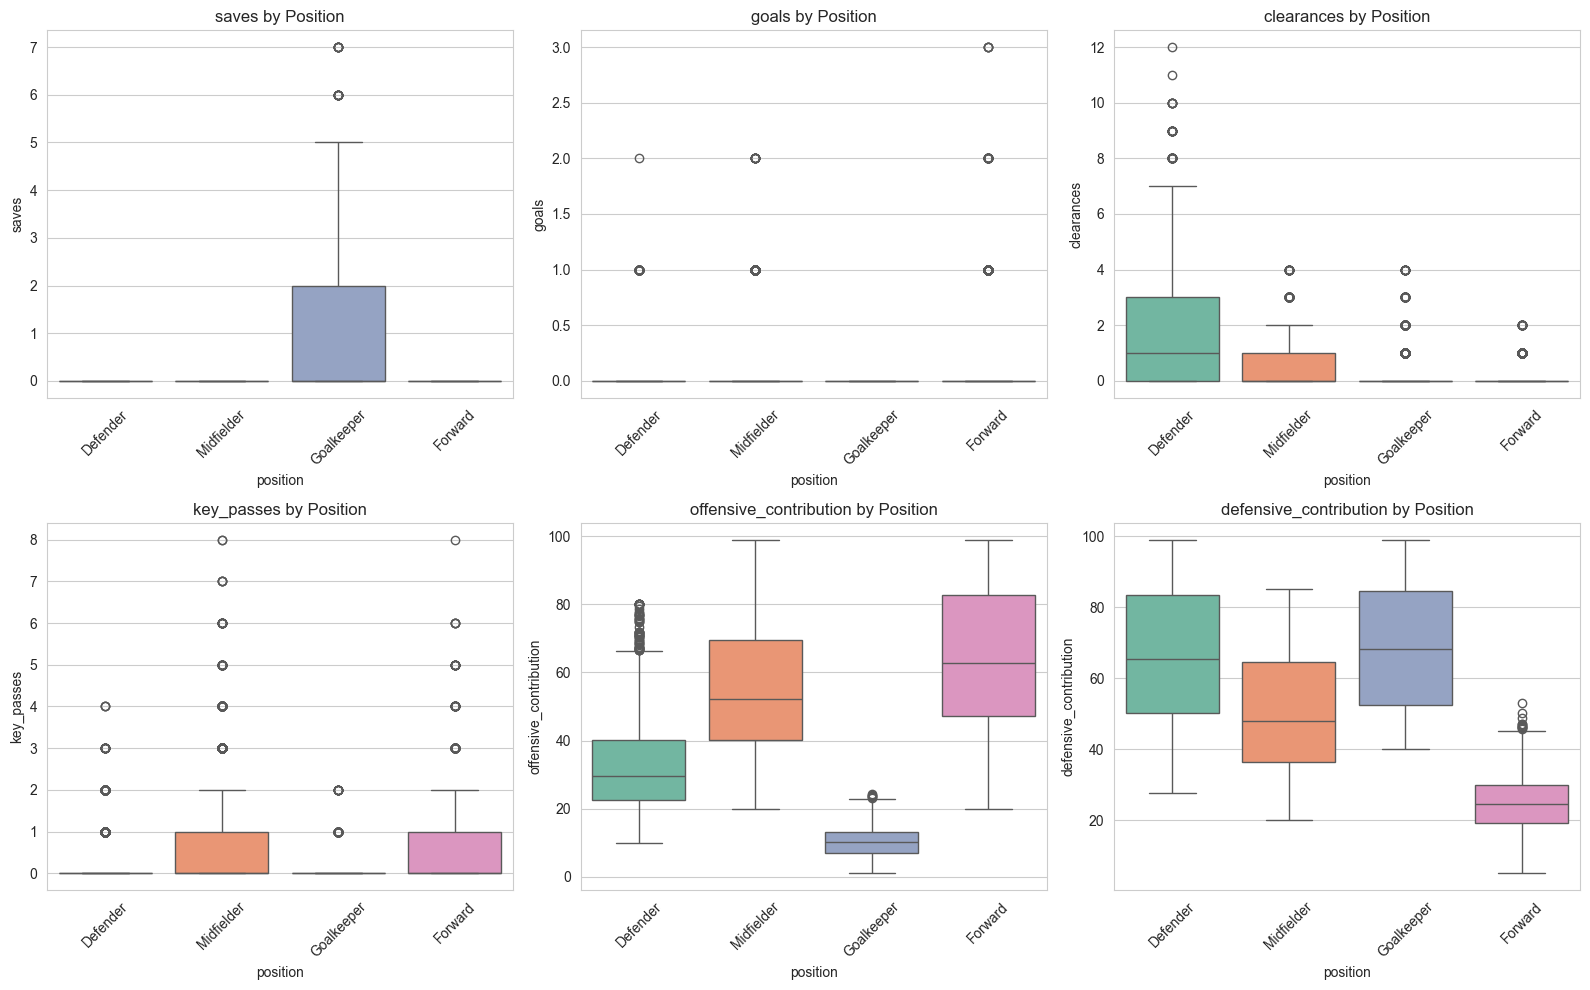

In [6]:
# Feature distributions by position — 6 discriminative features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
box_features = ['saves','goals','clearances','key_passes',
                'offensive_contribution','defensive_contribution']
for ax, feat in zip(axes.flat, box_features):
    sns.boxplot(data=df, x='position', y=feat, ax=ax, hue='position',
                palette='Set2', legend=False)
    ax.set_title(f'{feat} by Position')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

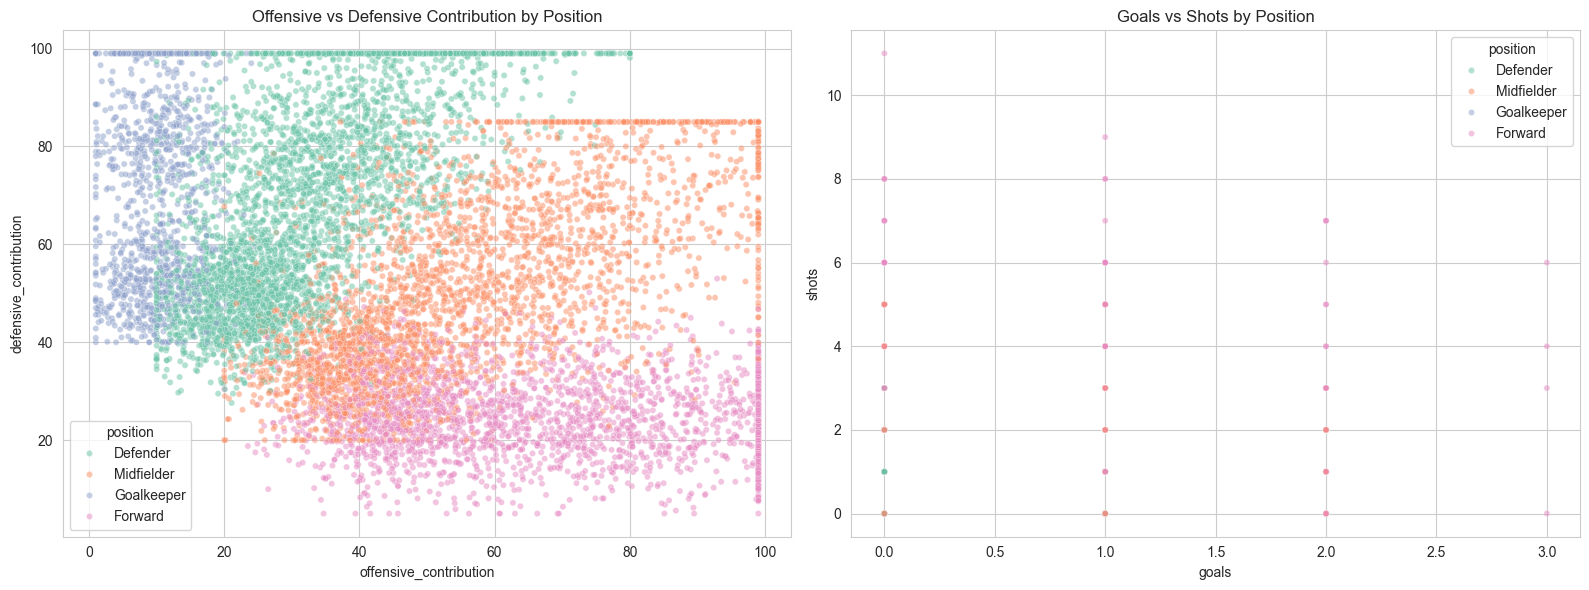

In [7]:
# Scatter plots showing feature-target relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='offensive_contribution', y='defensive_contribution',
                hue='position', palette='Set2', ax=axes[0], alpha=0.5, s=20)
axes[0].set_title('Offensive vs Defensive Contribution by Position')

sns.scatterplot(data=df, x='goals', y='shots',
                hue='position', palette='Set2', ax=axes[1], alpha=0.5, s=20)
axes[1].set_title('Goals vs Shots by Position')

plt.tight_layout()
plt.show()

<h3>5.3 Data Cleaning</h3>

In [8]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

# Cap extreme outliers on skewed count features at 1st/99th percentiles
cap_cols = ['shots','tackles','defensive_actions','accelerations','decelerations']
for col in cap_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)
    print(f"  Capped {col}: [{lower}, {upper}]")

Missing values: 0
Duplicate rows: 0
  Capped shots: [0.0, 4.0]
  Capped tackles: [0.0, 6.0]
  Capped defensive_actions: [0.0, 14.0]
  Capped accelerations: [0.0, 33.0]
  Capped decelerations: [0.0, 29.0]


<h3>5.4 Feature Engineering</h3>

In [9]:
# Feature 1: combined attacking output
df['goal_contribution'] = df['goals'] + df['assists']

# Feature 2: normalised aerial duel success (avoids division by zero)
df['duel_success_rate'] = df['aerial_duels_won'] / (df['aerial_duels_won'] + df['aerial_duels_lost'] + 1)

print("Engineered features — descriptive stats:")
print(df[['goal_contribution','duel_success_rate']].describe().round(3))

Engineered features — descriptive stats:
       goal_contribution  duel_success_rate
count          10000.000          10000.000
mean               0.108              0.200
std                0.361              0.270
min                0.000              0.000
25%                0.000              0.000
50%                0.000              0.000
75%                0.000              0.500
max                4.000              0.875


<h3>5.5 Preprocessing - Encoding, Scaling & Splitting</h3>

In [10]:
# Columns to drop: identifiers, high-cardinality categoricals, post-match outcomes (leakage)
drop_cols = ['player_id','player_name','nationality','team','jersey_number',
             'club_name','match_id','match_date','stadium','city',
             'opponent_team','tournament_stage','match_result',
             'goals_team','goals_opponent']

df_model = df.drop(columns=drop_cols)

# Encode target
le = LabelEncoder()
df_model['position'] = le.fit_transform(df_model['position'])
print("Position encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Binary encode preferred_foot
df_model['preferred_foot'] = df_model['preferred_foot'].map({'Left': 0, 'Right': 1})

# Separate features and target
X = df_model.drop(columns=['position'])
y = df_model['position']

# Stratified 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts(normalize=True).sort_index().round(4)}")

# Scale features — fit on train only (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\nScaled train — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

Position encoding: {'Defender': np.int64(0), 'Forward': np.int64(1), 'Goalkeeper': np.int64(2), 'Midfielder': np.int64(3)}

Train shape: (8000, 61), Test shape: (2000, 61)
Train class distribution:
position
0    0.3491
1    0.2284
2    0.1151
3    0.3074
Name: proportion, dtype: float64

Scaled train — mean: -0.0000, std: 1.0000


<h3>5.6 Model Training - SVC</h3>

In [11]:
# Compare kernels (linear vs rbf) and C values on a small grid
kernels = ['linear', 'rbf']
C_values = [0.1, 1, 10]
results = []

for kernel in kernels:
    for C in C_values:
        svc = SVC(kernel=kernel, C=C, random_state=RANDOM_STATE)
        svc.fit(X_train_scaled, y_train)
        acc = accuracy_score(y_test, svc.predict(X_test_scaled))
        results.append({'kernel': kernel, 'C': C, 'accuracy': acc})
        print(f"  kernel={kernel:8s}  C={C:<5}  accuracy={acc:.4f}")

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['accuracy'].idxmax()]
best_kernel = best_row['kernel']
best_C = best_row['C']
print(f"\nBest: kernel={best_kernel}, C={best_C}, accuracy={best_row['accuracy']:.4f}")

  kernel=linear    C=0.1    accuracy=0.9660
  kernel=linear    C=1      accuracy=0.9675
  kernel=linear    C=10     accuracy=0.9670
  kernel=rbf       C=0.1    accuracy=0.9395
  kernel=rbf       C=1      accuracy=0.9580
  kernel=rbf       C=10     accuracy=0.9600

Best: kernel=linear, C=1.0, accuracy=0.9675


In [12]:
# Train final model with best hyperparameters
# probability=True enables predict_proba for ROC-AUC
model = SVC(kernel=best_kernel, C=best_C, probability=True, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(f"SVC trained with kernel='{best_kernel}', C={best_C}")

SVC trained with kernel='linear', C=1.0


<h3>5.7 Model Evaluation </h3>

──────────────────────────────────────────────────
  Support Vector Machine (SVC) — Evaluation Metrics
──────────────────────────────────────────────────
  Accuracy : 0.9675
  Precision: 0.9675
  Recall   : 0.9675
  F1-score : 0.9675
  ROC-AUC  : 0.9975
──────────────────────────────────────────────────


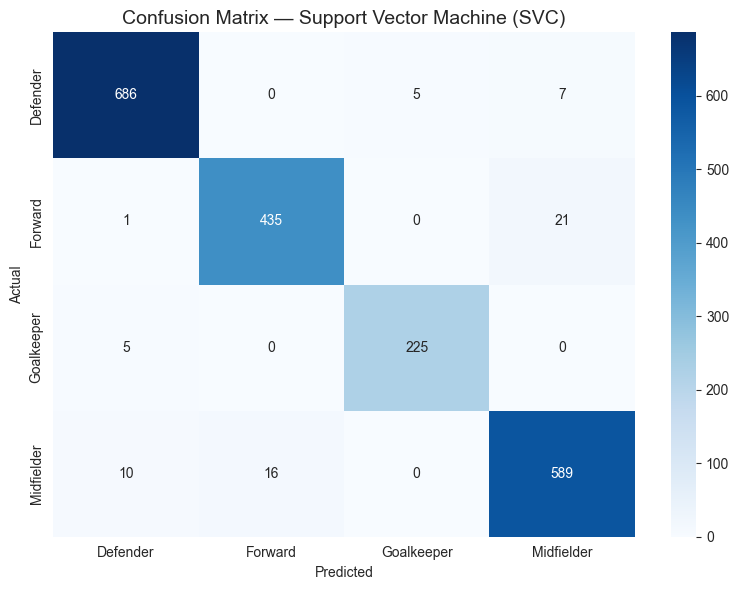


Classification Report:
              precision    recall  f1-score   support

    Defender       0.98      0.98      0.98       698
     Forward       0.96      0.95      0.96       457
  Goalkeeper       0.98      0.98      0.98       230
  Midfielder       0.95      0.96      0.96       615

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



In [13]:
# Predictions
y_pred = model.predict(X_test_scaled)

# Get probability estimates for ROC-AUC
y_proba = model.predict_proba(X_test_scaled)

# ── Metrics ──
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')
roc_auc   = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print("─" * 50)
print(f"  Support Vector Machine (SVC) — Evaluation Metrics")
print("─" * 50)
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-score : {f1:.4f}")
print(f"  ROC-AUC  : {roc_auc:.4f}")
print("─" * 50)

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Support Vector Machine (SVC)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

<h3>THE END FOR SUPPORT VECTOR MACHINE</h3>